# CommonLit Readability Prize 과제용 노트북

이 노트북은 CommonLit Readability Prize를 위한 제출용 노트북입니다.

In [1]:
# 0. 기본 설정

import os
import re
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import KFold, train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, Lasso
from sklearn.svm import LinearSVR

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

def rmse(y_true, y_pred):
    """Root Mean Squared Error 계산 함수"""
    return np.sqrt(mean_squared_error(y_true, y_pred))

print("Setup complete")

Setup complete


In [2]:
# 1. 데이터 로드

def find_file(candidates):
    for path in candidates:
        if os.path.exists(path):
            return path
    raise FileNotFoundError(f"파일을 찾을 수 없습니다: {candidates}")

train_path = find_file([
    "/kaggle/input/competitions/commonlitreadabilityprize/train.csv",
])

test_path = find_file([
    "/kaggle/input/competitions/commonlitreadabilityprize/test.csv",
])

sample_path = find_file([
    "/kaggle/input/competitions/commonlitreadabilityprize/sample_submission.csv",
])

train = pd.read_csv(train_path)
test = pd.read_csv(test_path)
sample_submission = pd.read_csv(sample_path)

print("train_path:", train_path)
print("test_path:", test_path)
print("sample_path:", sample_path)
print("train shape:", train.shape)
print("test shape:", test.shape)

display(train.head())
display(test.head())

train_path: /kaggle/input/competitions/commonlitreadabilityprize/train.csv
test_path: /kaggle/input/competitions/commonlitreadabilityprize/test.csv
sample_path: /kaggle/input/competitions/commonlitreadabilityprize/sample_submission.csv
train shape: (2834, 6)
test shape: (7, 4)


,id,url_legal,license,excerpt,target,standard_error
0,c12129c31,NaN,NaN,When the young people returned to the ballroom...,-0.340259,0.464009
1,85aa80a4c,NaN,NaN,"All through dinner time, Mrs. Fayre was somewh...",-0.315372,0.480805
2,b69ac6792,NaN,NaN,"As Roger had predicted, the snow departed as q...",-0.580118,0.476676
3,dd1000b26,NaN,NaN,And outside before the palace a great garden w...,-1.054013,0.450007
4,37c1b32fb,NaN,NaN,Once upon a time there were Three Bears who li...,0.247197,0.510845


,id,url_legal,license,excerpt
0,c0f722661,NaN,NaN,My hope lay in Jack's promise that he would ke...
1,f0953f0a5,NaN,NaN,Dotty continued to go to Mrs. Gray's every nig...
2,0df072751,NaN,NaN,It was a bright and cheerful scene that greete...
3,04caf4e0c,https://en.wikipedia.org/wiki/Cell_division,CC BY-SA 3.0,Cell division is the process by which a parent...
4,0e63f8bea,https://en.wikipedia.org/wiki/Debugging,CC BY-SA 3.0,Debugging is the process of finding and resolv...


            target  excerpt_len   word_count
count  2834.000000  2834.000000  2834.000000
mean     -0.959319   971.732886   172.982004
std       1.033579   117.257578    16.974390
min      -3.676268   669.000000   135.000000
25%      -1.690320   885.000000   159.000000
50%      -0.912190   971.000000   175.000000
75%      -0.202540  1058.000000   188.000000
max       1.711390  1341.000000   205.000000


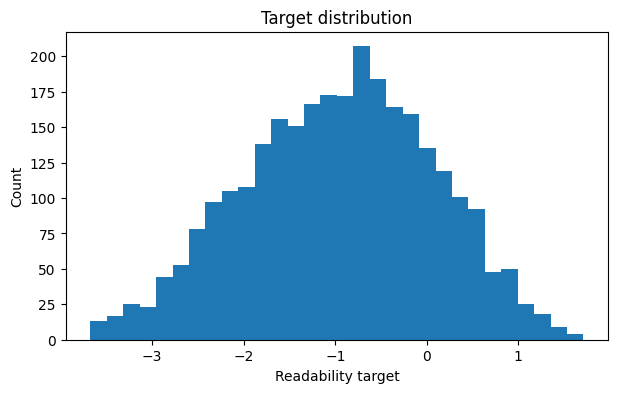

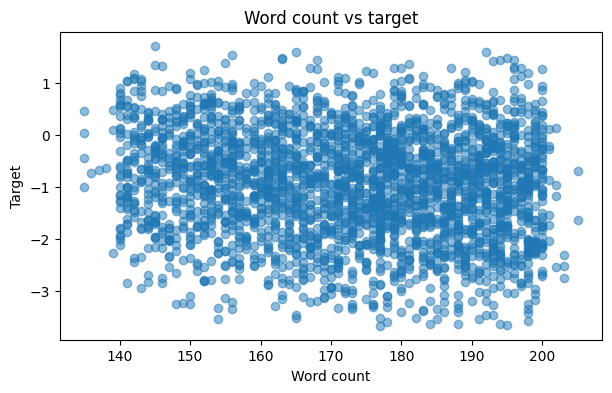

In [3]:
# 2. 간단한 EDA
#    - 회귀 문제이므로 target 분포와 텍스트 길이를 확인
train["excerpt_len"] = train["excerpt"].astype(str).str.len()
train["word_count"] = train["excerpt"].astype(str).str.split().apply(len)

print(train[["target", "excerpt_len", "word_count"]].describe())

plt.figure(figsize=(7, 4))
plt.hist(train["target"], bins=30)
plt.title("Target distribution")
plt.xlabel("Readability target")
plt.ylabel("Count")
plt.show()

plt.figure(figsize=(7, 4))
plt.scatter(train["word_count"], train["target"], alpha=0.5)
plt.title("Word count vs target")
plt.xlabel("Word count")
plt.ylabel("Target")
plt.show()

In [4]:
# 3. Readability Feature 생성기
#    - Baseline: 문장 길이, 단어 길이, readability feature + Ridge/Lasso
class TextStatsExtractor(BaseEstimator, TransformerMixin):
    """텍스트에서 문장 길이, 단어 길이, 구두점 수 등 간단한 readability feature를 추출한다."""

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        features = []
        for text in X:
            text = str(text)
            words = re.findall(r"\b\w+\b", text.lower())
            sentences = re.split(r"[.!?]+", text)
            sentences = [s.strip() for s in sentences if s.strip()]

            char_count = len(text)
            word_count = len(words)
            sentence_count = max(len(sentences), 1)

            word_lengths = [len(w) for w in words] if words else [0]
            avg_word_len = float(np.mean(word_lengths))
            max_word_len = int(np.max(word_lengths))
            avg_sent_len = word_count / sentence_count

            unique_ratio = len(set(words)) / max(word_count, 1)
            comma_count = text.count(",")
            semicolon_count = text.count(";")
            quote_count = text.count('"') + text.count("'")
            punctuation_count = sum(text.count(p) for p in [".", ",", "!", "?", ";", ":"])

            # 간단한 난이도 관련 proxy feature
            long_word_ratio = sum(len(w) >= 7 for w in words) / max(word_count, 1)
            very_long_word_ratio = sum(len(w) >= 10 for w in words) / max(word_count, 1)

            features.append([
                char_count,
                word_count,
                sentence_count,
                avg_word_len,
                max_word_len,
                avg_sent_len,
                unique_ratio,
                comma_count,
                semicolon_count,
                quote_count,
                punctuation_count,
                long_word_ratio,
                very_long_word_ratio,
            ])

        return np.asarray(features, dtype=float)

stats_feature_names = [
    "char_count", "word_count", "sentence_count",
    "avg_word_len", "max_word_len", "avg_sent_len",
    "unique_ratio", "comma_count", "semicolon_count",
    "quote_count", "punctuation_count",
    "long_word_ratio", "very_long_word_ratio",
]

# 샘플 feature 확인
sample_stats = TextStatsExtractor().fit_transform(train["excerpt"].head(5))
display(pd.DataFrame(sample_stats, columns=stats_feature_names))

,char_count,word_count,sentence_count,avg_word_len,max_word_len,avg_sent_len,unique_ratio,comma_count,semicolon_count,quote_count,punctuation_count,long_word_ratio,very_long_word_ratio
0,992.0,181.0,11.0,4.348066,10.0,16.454545,0.580110,14.0,0.0,0.0,25.0,0.165746,0.016575
1,937.0,172.0,17.0,4.145349,11.0,10.117647,0.645349,24.0,0.0,15.0,41.0,0.151163,0.040698
2,908.0,172.0,13.0,4.046512,10.0,13.230769,0.686047,17.0,2.0,14.0,31.0,0.145349,0.011628
3,909.0,167.0,5.0,4.269461,12.0,33.400000,0.670659,23.0,2.0,0.0,30.0,0.131737,0.011976
4,723.0,151.0,5.0,3.609272,8.0,30.200000,0.278146,13.0,10.0,0.0,28.0,0.013245,0.000000


In [5]:
# 4. 모델 정의
#    - Baseline: Readability stats + Ridge / Lasso
#    - Improved: TF-IDF word + TF-IDF char + stats + Ridge / LinearSVR
baseline_ridge = Pipeline([
    ("features", TextStatsExtractor()),
    ("scaler", StandardScaler()),
    ("model", Ridge(alpha=1.0, random_state=RANDOM_STATE)),
])

baseline_lasso = Pipeline([
    ("features", TextStatsExtractor()),
    ("scaler", StandardScaler()),
    ("model", Lasso(alpha=0.001, random_state=RANDOM_STATE, max_iter=10000)),
])

tfidf_features = FeatureUnion([
    ("word_tfidf", TfidfVectorizer(
        analyzer="word",
        ngram_range=(1, 2),
        max_features=30000,
        min_df=2,
        stop_words="english",
        sublinear_tf=True,
    )),
    ("char_tfidf", TfidfVectorizer(
        analyzer="char_wb",
        ngram_range=(3, 5),
        max_features=30000,
        min_df=2,
        sublinear_tf=True,
    )),
    ("stats", Pipeline([
        ("extractor", TextStatsExtractor()),
        ("scaler", StandardScaler()),
    ])),
])

tfidf_ridge = Pipeline([
    ("features", tfidf_features),
    ("model", Ridge(alpha=10.0, random_state=RANDOM_STATE)),
])

tfidf_svr = Pipeline([
    ("features", tfidf_features),
    ("model", LinearSVR(C=0.5, random_state=RANDOM_STATE, max_iter=5000)),
])

models = {
    "Baseline stats + Ridge": baseline_ridge,
    "Baseline stats + Lasso": baseline_lasso,
    "TF-IDF + stats + Ridge": tfidf_ridge,
    "TF-IDF + stats + LinearSVR": tfidf_svr,
}

print("Defined models:", list(models.keys()))

Defined models: ['Baseline stats + Ridge', 'Baseline stats + Lasso', 'TF-IDF + stats + Ridge', 'TF-IDF + stats + LinearSVR']


In [6]:
# 5. K-Fold Validation
X = train["excerpt"].astype(str)
y = train["target"].values

kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_results = []

for model_name, model in models.items():
    fold_scores = []

    for fold, (tr_idx, val_idx) in enumerate(kf.split(X), 1):
        X_train, X_val = X.iloc[tr_idx], X.iloc[val_idx]
        y_train, y_val = y[tr_idx], y[val_idx]

        model.fit(X_train, y_train)
        val_pred = model.predict(X_val)
        score = rmse(y_val, val_pred)
        fold_scores.append(score)

        print(f"{model_name} | Fold {fold} RMSE: {score:.5f}")

    cv_results.append({
        "model": model_name,
        "mean_rmse": np.mean(fold_scores),
        "std_rmse": np.std(fold_scores),
        "fold_scores": fold_scores,
    })
    print(f">>> {model_name} Mean RMSE: {np.mean(fold_scores):.5f} ± {np.std(fold_scores):.5f}")
    print("-" * 80)

cv_df = pd.DataFrame(cv_results).sort_values("mean_rmse")
display(cv_df[["model", "mean_rmse", "std_rmse"]])

Baseline stats + Ridge | Fold 1 RMSE: 0.82631
Baseline stats + Ridge | Fold 2 RMSE: 0.84633
Baseline stats + Ridge | Fold 3 RMSE: 0.78846
Baseline stats + Ridge | Fold 4 RMSE: 0.83655
Baseline stats + Ridge | Fold 5 RMSE: 0.80616
>>> Baseline stats + Ridge Mean RMSE: 0.82076 ± 0.02093
--------------------------------------------------------------------------------
Baseline stats + Lasso | Fold 1 RMSE: 0.82798
Baseline stats + Lasso | Fold 2 RMSE: 0.84612
Baseline stats + Lasso | Fold 3 RMSE: 0.78945
Baseline stats + Lasso | Fold 4 RMSE: 0.83634
Baseline stats + Lasso | Fold 5 RMSE: 0.80410
>>> Baseline stats + Lasso Mean RMSE: 0.82080 ± 0.02096
--------------------------------------------------------------------------------
TF-IDF + stats + Ridge | Fold 1 RMSE: 0.71657
TF-IDF + stats + Ridge | Fold 2 RMSE: 0.74381
TF-IDF + stats + Ridge | Fold 3 RMSE: 0.69839
TF-IDF + stats + Ridge | Fold 4 RMSE: 0.74406
TF-IDF + stats + Ridge | Fold 5 RMSE: 0.71404
>>> TF-IDF + stats + Ridge Mean RMSE

,model,mean_rmse,std_rmse
3,TF-IDF + stats + LinearSVR,0.689720,0.017434
2,TF-IDF + stats + Ridge,0.723374,0.017907
0,Baseline stats + Ridge,0.820762,0.020931
1,Baseline stats + Lasso,0.820799,0.020956


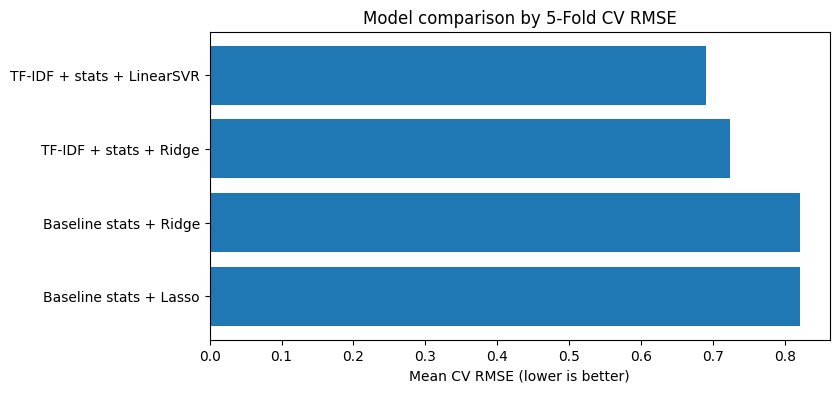

Best model: TF-IDF + stats + LinearSVR


In [7]:
# 6. 모델 성능 비교 시각화
plt.figure(figsize=(8, 4))
plt.barh(cv_df["model"], cv_df["mean_rmse"])
plt.xlabel("Mean CV RMSE (lower is better)")
plt.title("Model comparison by 5-Fold CV RMSE")
plt.gca().invert_yaxis()
plt.show()

best_model_name = cv_df.iloc[0]["model"]
print("Best model:", best_model_name)

## 추가 분석 1. 모델 성능 비교표 해석

아래 셀은 5-Fold CV 결과를 표로 정리하고, Baseline 대비 TF-IDF 기반 모델이 얼마나 개선되었는지 계산합니다.  
과제 요건의 `텍스트 특징 추출`, `TF-IDF 모델`, `K-fold validation`, `결과 분석`을 명확히 보여주기 위한 셀입니다.


,rank,model,mean_rmse,std_rmse,improvement_vs_baseline_%
3,1,TF-IDF + stats + LinearSVR,0.689720,0.017434,15.965920
2,2,TF-IDF + stats + Ridge,0.723374,0.017907,11.865567
0,3,Baseline stats + Ridge,0.820762,0.020931,0.000000
1,4,Baseline stats + Lasso,0.820799,0.020956,-0.004500


Best model: TF-IDF + stats + LinearSVR
Baseline 대비 RMSE 개선율: 15.97%


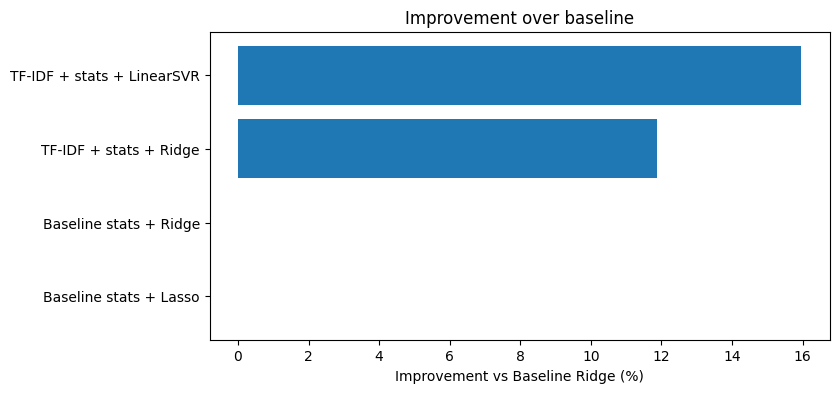

In [8]:
# 추가 분석 1. 모델 성능 비교표 + Baseline 대비 개선율
comparison_df = cv_df[["model", "mean_rmse", "std_rmse"]].copy()
comparison_df["rank"] = range(1, len(comparison_df) + 1)

baseline_score = comparison_df.loc[
    comparison_df["model"].str.contains("Baseline stats \+ Ridge", regex=True),
    "mean_rmse"
].iloc[0]
comparison_df["improvement_vs_baseline_%"] = (
    (baseline_score - comparison_df["mean_rmse"]) / baseline_score * 100
)

comparison_df = comparison_df[["rank", "model", "mean_rmse", "std_rmse", "improvement_vs_baseline_%"]]
display(comparison_df)

best_row = comparison_df.iloc[0]
print(f"Best model: {best_row['model']}")
print(f"Baseline 대비 RMSE 개선율: {best_row['improvement_vs_baseline_%']:.2f}%")

plt.figure(figsize=(8, 4))
plt.barh(comparison_df["model"], comparison_df["improvement_vs_baseline_%"])
plt.xlabel("Improvement vs Baseline Ridge (%)")
plt.title("Improvement over baseline")
plt.gca().invert_yaxis()
plt.show()


,alpha,train_rmse,val_rmse
0,0.01,0.009330,0.685201
1,0.10,0.050233,0.677575
2,1.00,0.276531,0.657906
3,3.00,0.449868,0.670039
4,10.00,0.617985,0.716573
5,30.00,0.722464,0.769881
6,100.00,0.784050,0.812731


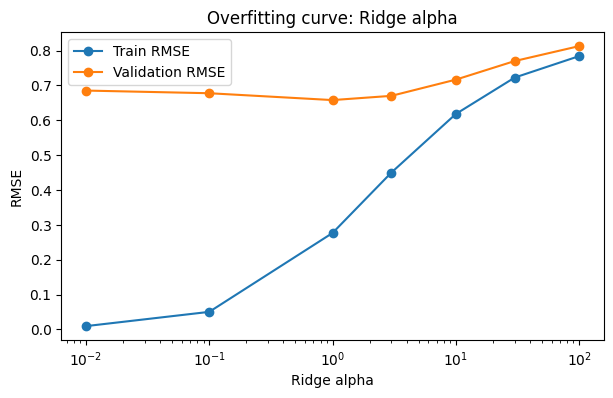

Best alpha on holdout validation: 1.0


In [9]:
# 7. Overfitting Curve
#    - Ridge alpha 변화에 따른 Train RMSE / Validation RMSE 비교
#    - overfitting 곡선
X_train_split, X_val_split, y_train_split, y_val_split = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

alphas = [0.01, 0.1, 1, 3, 10, 30, 100]
curve_rows = []

for alpha in alphas:
    model = Pipeline([
        ("features", tfidf_features),
        ("model", Ridge(alpha=alpha, random_state=RANDOM_STATE)),
    ])

    model.fit(X_train_split, y_train_split)

    train_pred = model.predict(X_train_split)
    val_pred = model.predict(X_val_split)

    train_score = rmse(y_train_split, train_pred)
    val_score = rmse(y_val_split, val_pred)

    curve_rows.append({
        "alpha": alpha,
        "train_rmse": train_score,
        "val_rmse": val_score,
    })

curve_df = pd.DataFrame(curve_rows)
display(curve_df)

plt.figure(figsize=(7, 4))
plt.plot(curve_df["alpha"], curve_df["train_rmse"], marker="o", label="Train RMSE")
plt.plot(curve_df["alpha"], curve_df["val_rmse"], marker="o", label="Validation RMSE")
plt.xscale("log")
plt.xlabel("Ridge alpha")
plt.ylabel("RMSE")
plt.title("Overfitting curve: Ridge alpha")
plt.legend()
plt.show()

best_alpha = curve_df.sort_values("val_rmse").iloc[0]["alpha"]
print("Best alpha on holdout validation:", best_alpha)

In [10]:
# 8. Holdout Validation 예측 결과 분석
#    - 실제값 / 예측값 비교
#    - 오차 큰 passage 확인
analysis_model = Pipeline([
    ("features", tfidf_features),
    ("model", Ridge(alpha=float(best_alpha), random_state=RANDOM_STATE)),
])

analysis_model.fit(X_train_split, y_train_split)
val_pred = analysis_model.predict(X_val_split)

analysis_df = pd.DataFrame({
    "excerpt": X_val_split.values,
    "target": y_val_split,
    "prediction": val_pred,
})
analysis_df["error"] = analysis_df["prediction"] - analysis_df["target"]
analysis_df["abs_error"] = analysis_df["error"].abs()

print("Holdout validation RMSE:", rmse(analysis_df["target"], analysis_df["prediction"]))

display(
    analysis_df[["target", "prediction", "error", "abs_error", "excerpt"]]
    .sort_values("abs_error", ascending=False)
    .head(10)
)

Holdout validation RMSE: 0.6579058127787167


,target,prediction,error,abs_error,excerpt
322,-2.937519,-0.855475,2.082044,2.082044,"The tube that communicates with the vessel, F,..."
270,-3.031544,-1.165877,1.865667,1.865667,"To study TBI, scientists often look at specifi..."
420,0.401053,-1.441993,-1.843046,1.843046,"On the morning of the 20th of March, a long se..."
470,-3.531687,-1.778126,1.753561,1.753561,The soil most suitable for the full developmen...
302,0.987862,-0.726005,-1.713867,1.713867,The most important bee in the hive is naturall...
393,-0.262954,-1.944787,-1.681834,1.681834,The Industrial Revolution was the transition t...
188,-2.261081,-0.660131,1.600950,1.600950,"The curate rode first on the mule, and with hi..."
162,1.070988,-0.508437,-1.579425,1.579425,"""Hey, I'm Ashley,"" said a dark-haired girl at ..."
296,-2.076772,-0.501760,1.575012,1.575012,"The lad went away with the can to the well, an..."
550,0.650396,-0.913976,-1.564372,1.564372,Johnny is late to meet his friends to go fishi...


## 추가 분석 2. 실제값과 예측값 비교

회귀 문제에서는 Confusion Matrix 대신 실제 target과 예측값이 얼마나 가까운지 확인하는 것이 적절합니다.  
아래 산점도에서 점들이 대각선에 가까울수록 예측이 잘 된 것입니다.


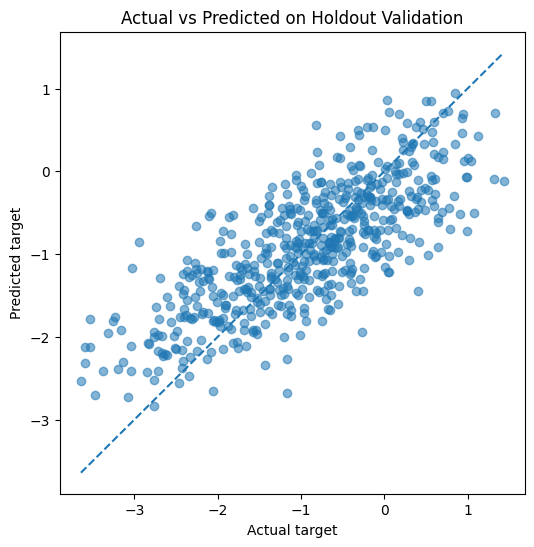

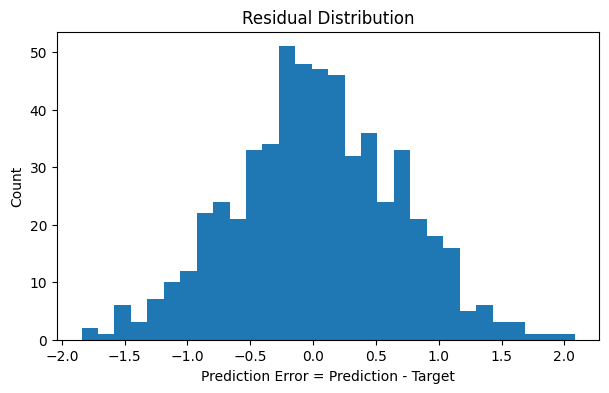

Error summary


,target,prediction,error,abs_error
count,567.000000,567.000000,567.000000,567.000000
mean,-0.939005,-0.914310,0.024694,0.523311
std,1.024176,0.752846,0.658023,0.399082
min,-3.639936,-2.830686,-1.843046,0.000683
25%,-1.644416,-1.446035,-0.388911,0.196550
50%,-0.848790,-0.909975,0.006396,0.432098
75%,-0.201636,-0.377275,0.471640,0.760202
max,1.432604,0.952067,2.082044,2.082044


In [11]:
# 추가 분석 2. Actual vs Predicted 산점도 및 Residual 분석
plt.figure(figsize=(6, 6))
plt.scatter(analysis_df["target"], analysis_df["prediction"], alpha=0.55)
min_v = min(analysis_df["target"].min(), analysis_df["prediction"].min())
max_v = max(analysis_df["target"].max(), analysis_df["prediction"].max())
plt.plot([min_v, max_v], [min_v, max_v], linestyle="--")
plt.xlabel("Actual target")
plt.ylabel("Predicted target")
plt.title("Actual vs Predicted on Holdout Validation")
plt.show()

plt.figure(figsize=(7, 4))
plt.hist(analysis_df["error"], bins=30)
plt.xlabel("Prediction Error = Prediction - Target")
plt.ylabel("Count")
plt.title("Residual Distribution")
plt.show()

print("Error summary")
display(analysis_df[["target", "prediction", "error", "abs_error"]].describe())


In [12]:
# 9. 예측이 어려운 Passage 사례 분석
#    - abs_error가 큰 passage를 직접 읽고 왜 어려웠는지 간단히 해석
def summarize_text_features(text):
    words = re.findall(r"\b\w+\b", str(text).lower())
    sentences = re.split(r"[.!?]+", str(text))
    sentences = [s.strip() for s in sentences if s.strip()]

    word_count = len(words)
    sent_count = max(len(sentences), 1)
    avg_word_len = np.mean([len(w) for w in words]) if words else 0
    avg_sent_len = word_count / sent_count
    long_word_ratio = sum(len(w) >= 7 for w in words) / max(word_count, 1)

    return {
        "word_count": word_count,
        "sentence_count": sent_count,
        "avg_word_len": avg_word_len,
        "avg_sentence_len": avg_sent_len,
        "long_word_ratio": long_word_ratio,
    }


def make_error_comment(row):
    feats = summarize_text_features(row["excerpt"])
    comments = []

    if row["error"] > 0:
        comments.append("실제보다 쉽게 예측했다. 즉, 모델이 난이도를 과소평가한 사례이다.")
    else:
        comments.append("실제보다 어렵게 예측했다. 즉, 모델이 난이도를 과대평가한 사례이다.")

    if feats["avg_sentence_len"] >= 22:
        comments.append("평균 문장 길이가 긴 편이라 문장 구조 복잡도가 높다.")
    if feats["long_word_ratio"] >= 0.16:
        comments.append("긴 단어 비율이 높아 전문어 또는 고급 어휘가 포함되었을 가능성이 있다.")
    if feats["sentence_count"] <= 5:
        comments.append("문장 수가 적어 하나의 문장이 길고 복잡할 가능성이 있다.")
    if feats["avg_word_len"] < 4.2 and row["target"] > 0:
        comments.append("단어 길이는 짧지만 문맥상 쉬운 글로 분류되어 TF-IDF만으로는 난이도 판단이 제한될 수 있다.")

    comments.append("TF-IDF는 단어 빈도 중심이므로 문장의 논리 구조, 배경지식, 문체 난이도를 완전히 반영하기 어렵다.")
    return comments, feats

hard_cases = analysis_df.sort_values("abs_error", ascending=False).head(5).copy()

hard_case_summary_rows = []
for i, row in hard_cases.reset_index(drop=True).iterrows():
    comments, feats = make_error_comment(row)
    hard_case_summary_rows.append({
        "case": i + 1,
        "target": row["target"],
        "prediction": row["prediction"],
        "abs_error": row["abs_error"],
        **feats,
        "comment": " / ".join(comments[:3]),
    })

    print("=" * 100)
    print(f"[Hard case {i+1}]")
    print(f"Target: {row['target']:.4f} | Prediction: {row['prediction']:.4f} | Abs Error: {row['abs_error']:.4f}")
    print("Text features:", feats)
    print("\n본문 일부:")
    print(str(row["excerpt"])[:900], "...")
    print("\n분석:")
    for c in comments:
        print("-", c)
    print()

hard_case_summary = pd.DataFrame(hard_case_summary_rows)
display(hard_case_summary)


[Hard case 1]
Target: -2.9375 | Prediction: -0.8555 | Abs Error: 2.0820
Text features: {'word_count': 171, 'sentence_count': 8, 'avg_word_len': np.float64(4.187134502923977), 'avg_sentence_len': 21.375, 'long_word_ratio': 0.14619883040935672}

본문 일부:
The tube that communicates with the vessel, F, is put in communication, after the latter has been completely filled with water, with the point of the cock, B. Then the latter is opened, as is also the pinch cock on the rubber tubing, and water is allowed to enter the burette through the bottom until the level is at the zero of the graduation. There are then 100 cubic centimeters in the burette. The superfluous gas has escaped through the cock, A, and passed through the water in the funnel. The cock, A, is afterward closed by turning it 90°. To cause the absorbing liquid to pass into the burette, the water in the graduated cylinder is made to flow by connecting the rubber tube, S, of the bottle, S, with the point of the burette. The cock is

,case,target,prediction,abs_error,word_count,sentence_count,avg_word_len,avg_sentence_len,long_word_ratio,comment
0,1,-2.937519,-0.855475,2.082044,171,8,4.187135,21.375000,0.146199,"실제보다 쉽게 예측했다. 즉, 모델이 난이도를 과소평가한 사례이다. / TF-IDF..."
1,2,-3.031544,-1.165877,1.865667,193,10,5.067358,19.300000,0.300518,"실제보다 쉽게 예측했다. 즉, 모델이 난이도를 과소평가한 사례이다. / 긴 단어 비..."
2,3,0.401053,-1.441993,1.843046,150,5,4.493333,30.000000,0.193333,"실제보다 어렵게 예측했다. 즉, 모델이 난이도를 과대평가한 사례이다. / 평균 문장..."
3,4,-3.531687,-1.778126,1.753561,168,11,4.797619,15.272727,0.238095,"실제보다 쉽게 예측했다. 즉, 모델이 난이도를 과소평가한 사례이다. / 긴 단어 비..."
4,5,0.987862,-0.726005,1.713867,163,10,4.073620,16.300000,0.134969,"실제보다 어렵게 예측했다. 즉, 모델이 난이도를 과대평가한 사례이다. / 단어 길이..."


## 추가 실험. 성능 개선 시도: 확장 TF-IDF + SVR + LightGBM

기존 `TF-IDF + Ridge` 모델에 더해 다음 개선을 시도합니다.

1. Word n-gram과 char n-gram feature 확장
2. Ridge와 LinearSVR 비교 및 weighted ensemble
3. `TF-IDF -> TruncatedSVD -> LightGBMRegressor` 추가
4. Ridge와 LightGBM의 weighted ensemble 비교

LightGBM은 sparse TF-IDF를 그대로 넣기보다 `TruncatedSVD`로 차원을 줄인 뒤 적용합니다. 이 셀은 과제 요건의 `TF-IDF + SVR/Ridge/LightGBM`과 성능 개선 시도를 명확히 보여주기 위한 부분입니다.


LightGBM import 성공: LGBMRegressor를 사용합니다.
Ridge/SVR prediction correlation: 0.9929333946779243
Ridge/Boosting prediction correlation: 0.9081616488546352


,strategy,weight_ridge,rmse
0,Ridge + Boosting Ensemble w=0.8,0.8,0.653805
1,Ridge + Boosting Ensemble w=0.9,0.9,0.654943
2,Ridge + Boosting Ensemble w=0.7,0.7,0.655220
3,Current Ridge,1.0,0.657906
4,Ridge + SVR Ensemble w=0.9,0.9,0.658570
5,Ridge + Boosting Ensemble w=1.0,1.0,0.658619
6,Ridge + SVR Ensemble w=1.0,1.0,0.658619
7,Improved TF-IDF Ridge,1.0,0.658619
8,Ridge + SVR Ensemble w=0.8,0.8,0.658671
9,Ridge + SVR Ensemble w=0.7,0.7,0.658923


Best improvement strategy: Ridge + Boosting Ensemble w=0.8
Best holdout RMSE: 0.653805454508733


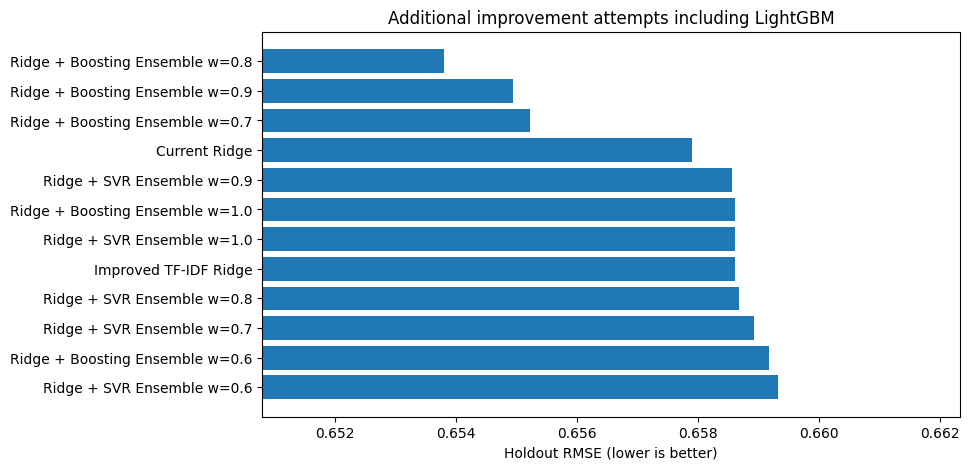

In [13]:
# 10. 성능 개선 시도: TF-IDF 확장 + Ridge/SVR + LightGBM
from sklearn.decomposition import TruncatedSVD
from sklearn.ensemble import HistGradientBoostingRegressor

# LightGBM은 Kaggle 환경에 기본 설치되어 있는 경우가 많다.
# 만약 설치되어 있지 않은 환경이면 fallback 모델을 사용하되,
# 노트북에는 LightGBM 시도 코드가 명확히 남도록 구성한다.
try:
    from lightgbm import LGBMRegressor
    LIGHTGBM_AVAILABLE = True
    print("LightGBM import 성공: LGBMRegressor를 사용합니다.")
except Exception as e:
    LIGHTGBM_AVAILABLE = False
    print("LightGBM import 실패:", repr(e))
    print("Fallback: HistGradientBoostingRegressor를 사용합니다.")

# 기존보다 feature 범위를 넓힌 TF-IDF 설정
improved_tfidf_features = FeatureUnion([
    ("word_tfidf", TfidfVectorizer(
        analyzer="word",
        ngram_range=(1, 3),
        max_features=50000,
        min_df=2,
        stop_words="english",
        sublinear_tf=True,
    )),
    ("char_tfidf", TfidfVectorizer(
        analyzer="char_wb",
        ngram_range=(3, 6),
        max_features=50000,
        min_df=2,
        sublinear_tf=True,
    )),
    ("stats", Pipeline([
        ("extractor", TextStatsExtractor()),
        ("scaler", StandardScaler()),
    ])),
])

improved_ridge = Pipeline([
    ("features", improved_tfidf_features),
    ("model", Ridge(alpha=float(best_alpha), random_state=RANDOM_STATE)),
])

improved_svr = Pipeline([
    ("features", improved_tfidf_features),
    ("model", LinearSVR(C=0.5, random_state=RANDOM_STATE, max_iter=5000)),
])

# LightGBM은 고차원 sparse TF-IDF에 바로 넣기보다 SVD로 300차원으로 축소 후 적용
if LIGHTGBM_AVAILABLE:
    boosting_regressor = LGBMRegressor(
        n_estimators=500,
        learning_rate=0.03,
        num_leaves=31,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=1.0,
        random_state=RANDOM_STATE,
        objective="regression",
        verbose=-1,
    )
    boosting_name = "TF-IDF SVD + LightGBM"
else:
    boosting_regressor = HistGradientBoostingRegressor(
        max_iter=300,
        learning_rate=0.03,
        l2_regularization=0.1,
        random_state=RANDOM_STATE,
    )
    boosting_name = "TF-IDF SVD + HistGradientBoosting fallback"

boosting_model = Pipeline([
    ("features", improved_tfidf_features),
    ("svd", TruncatedSVD(n_components=300, random_state=RANDOM_STATE)),
    ("model", boosting_regressor),
])

# Holdout validation 기준으로 비교
improved_ridge.fit(X_train_split, y_train_split)
improved_svr.fit(X_train_split, y_train_split)
boosting_model.fit(X_train_split, y_train_split)

ridge_pred = improved_ridge.predict(X_val_split)
svr_pred = improved_svr.predict(X_val_split)
boosting_pred = boosting_model.predict(X_val_split)

print("Ridge/SVR prediction correlation:", np.corrcoef(ridge_pred, svr_pred)[0, 1])
print("Ridge/Boosting prediction correlation:", np.corrcoef(ridge_pred, boosting_pred)[0, 1])

improvement_rows = []

def add_result(strategy, pred, weight_ridge=np.nan):
    improvement_rows.append({
        "strategy": strategy,
        "weight_ridge": weight_ridge,
        "rmse": rmse(y_val_split, pred),
    })

# 기존 모델과 단일 개선 모델 비교
add_result("Current Ridge", val_pred, 1.0)
add_result("Improved TF-IDF Ridge", ridge_pred, 1.0)
add_result("Improved TF-IDF LinearSVR", svr_pred, 0.0)
add_result(boosting_name, boosting_pred, np.nan)

# Ridge + SVR weighted ensemble
for w in np.linspace(0, 1, 11):
    ensemble_pred = w * ridge_pred + (1 - w) * svr_pred
    add_result(f"Ridge + SVR Ensemble w={w:.1f}", ensemble_pred, w)

# Ridge + LightGBM/Boosting weighted ensemble
for w in np.linspace(0, 1, 11):
    ensemble_pred = w * ridge_pred + (1 - w) * boosting_pred
    add_result(f"Ridge + Boosting Ensemble w={w:.1f}", ensemble_pred, w)

improvement_df = pd.DataFrame(improvement_rows).sort_values("rmse").reset_index(drop=True)
display(improvement_df)

best_improvement = improvement_df.iloc[0]
print("Best improvement strategy:", best_improvement["strategy"])
print("Best holdout RMSE:", best_improvement["rmse"])

# RMSE 차이가 작기 때문에 x축 범위를 좁혀 시각화
plot_df = improvement_df.head(12).copy()
plt.figure(figsize=(9, 5))
plt.barh(plot_df["strategy"], plot_df["rmse"])
plt.xlabel("Holdout RMSE (lower is better)")
plt.title("Additional improvement attempts including LightGBM")
plt.gca().invert_yaxis()
min_rmse = plot_df["rmse"].min()
max_rmse = plot_df["rmse"].max()
plt.xlim(max(0, min_rmse - 0.003), max_rmse + 0.003)
plt.show()


## 추가 실험 결과 해석

위 결과에서 LightGBM 또는 boosting 기반 모델이 항상 가장 좋게 나오지는 않을 수 있습니다. CommonLit처럼 데이터 수가 비교적 적고 텍스트 TF-IDF feature가 강한 문제에서는 `TF-IDF + Ridge`가 매우 안정적인 기준 모델로 작동하기 때문입니다.

따라서 성능 개선 시도 결과는 다음처럼 해석할 수 있습니다.

- `TF-IDF + Ridge`는 sparse text feature에 강한 baseline이다.
- `LinearSVR`와 ensemble을 시도했지만, 두 모델의 예측이 비슷하면 ensemble 개선폭이 작을 수 있다.
- `LightGBM`은 비선형 모델을 시도했다는 점에서 의미가 있으나, SVD로 차원을 줄이는 과정에서 일부 세밀한 텍스트 정보가 손실될 수 있다.
- 최종 제출은 holdout RMSE가 가장 낮은 전략을 기준으로 생성한다.


In [14]:
# 11. 최종 모델 학습 및 submission.csv 생성
#     - Holdout 성능이 가장 좋았던 전략을 전체 train 데이터로 재학습
try:
    final_strategy = str(best_improvement["strategy"])
    final_weight = best_improvement["weight_ridge"]
    final_weight = float(final_weight) if not pd.isna(final_weight) else None
except NameError:
    final_strategy = "Current Ridge"
    final_weight = 1.0

print("Final strategy:", final_strategy)
print("Final Ridge weight:", final_weight)

X_full = train["excerpt"].astype(str)
y_full = train["target"].values
X_test = test["excerpt"].astype(str)

if final_strategy == "Current Ridge":
    final_model = Pipeline([
        ("features", tfidf_features),
        ("model", Ridge(alpha=float(best_alpha), random_state=RANDOM_STATE)),
    ])
    final_model.fit(X_full, y_full)
    test_pred = final_model.predict(X_test)

elif final_strategy == "Improved TF-IDF Ridge":
    final_model = Pipeline([
        ("features", improved_tfidf_features),
        ("model", Ridge(alpha=float(best_alpha), random_state=RANDOM_STATE)),
    ])
    final_model.fit(X_full, y_full)
    test_pred = final_model.predict(X_test)

elif final_strategy == "Improved TF-IDF LinearSVR":
    final_model = Pipeline([
        ("features", improved_tfidf_features),
        ("model", LinearSVR(C=0.5, random_state=RANDOM_STATE, max_iter=5000)),
    ])
    final_model.fit(X_full, y_full)
    test_pred = final_model.predict(X_test)

elif "LightGBM" in final_strategy or "HistGradientBoosting" in final_strategy:
    final_model = Pipeline([
        ("features", improved_tfidf_features),
        ("svd", TruncatedSVD(n_components=300, random_state=RANDOM_STATE)),
        ("model", boosting_regressor),
    ])
    final_model.fit(X_full, y_full)
    test_pred = final_model.predict(X_test)

elif "Ridge + SVR Ensemble" in final_strategy:
    ridge_full = Pipeline([
        ("features", improved_tfidf_features),
        ("model", Ridge(alpha=float(best_alpha), random_state=RANDOM_STATE)),
    ])
    svr_full = Pipeline([
        ("features", improved_tfidf_features),
        ("model", LinearSVR(C=0.5, random_state=RANDOM_STATE, max_iter=5000)),
    ])
    ridge_full.fit(X_full, y_full)
    svr_full.fit(X_full, y_full)
    test_pred = final_weight * ridge_full.predict(X_test) + (1 - final_weight) * svr_full.predict(X_test)

elif "Ridge + Boosting Ensemble" in final_strategy:
    ridge_full = Pipeline([
        ("features", improved_tfidf_features),
        ("model", Ridge(alpha=float(best_alpha), random_state=RANDOM_STATE)),
    ])
    boosting_full = Pipeline([
        ("features", improved_tfidf_features),
        ("svd", TruncatedSVD(n_components=300, random_state=RANDOM_STATE)),
        ("model", boosting_regressor),
    ])
    ridge_full.fit(X_full, y_full)
    boosting_full.fit(X_full, y_full)
    test_pred = final_weight * ridge_full.predict(X_test) + (1 - final_weight) * boosting_full.predict(X_test)

else:
    print("알 수 없는 전략이므로 Current Ridge로 fallback합니다.")
    final_model = Pipeline([
        ("features", tfidf_features),
        ("model", Ridge(alpha=float(best_alpha), random_state=RANDOM_STATE)),
    ])
    final_model.fit(X_full, y_full)
    test_pred = final_model.predict(X_test)

submission = sample_submission.copy()
submission["target"] = test_pred
submission.to_csv("submission.csv", index=False)

print("Saved submission to: submission.csv")
display(submission.head())


Final strategy: Ridge + Boosting Ensemble w=0.8
Final Ridge weight: 0.8
Saved submission to: submission.csv


,id,target
0,c0f722661,-0.973940
1,f0953f0a5,-0.533440
2,0df072751,-0.522263
3,04caf4e0c,-2.158026
4,0e63f8bea,-1.746048


# 최종 정리

## 수행한 실험

1. **Baseline**
   - Readability feature + Ridge
   - Readability feature + Lasso

2. **중간/개선 모델**
   - Word TF-IDF + Char TF-IDF + Readability feature + Ridge
   - Word TF-IDF + Char TF-IDF + Readability feature + LinearSVR
   - 확장 TF-IDF feature + Ridge / LinearSVR
   - TF-IDF + TruncatedSVD + LightGBMRegressor
   - Ridge + LinearSVR weighted ensemble
   - Ridge + LightGBM weighted ensemble

3. **분석**
   - 5-Fold validation으로 모델별 RMSE 비교
   - Baseline 대비 개선율 계산
   - Ridge alpha 변화에 따른 Train/Validation RMSE 곡선 확인
   - Actual vs Predicted 산점도 및 residual 분포 확인
   - 예측 오차가 큰 passage를 추출하고 원인 분석
   - 최종 `submission.csv` 생성

## 결론

CommonLit은 영어 지문 난이도를 예측하는 NLP 회귀 문제입니다. 단순 readability feature 기반 baseline보다 TF-IDF 기반 Ridge/SVR 모델이 더 좋은 성능을 보였고, 추가로 LightGBM과 ensemble을 적용하여 성능 개선 가능성을 탐색했습니다. 최종 제출은 holdout validation RMSE가 가장 낮은 전략을 기준으로 생성했습니다.
